# HW4 — NN vs CNN for USPS Digit Classification

**Dohyeong Ryu**

A fully-connected Neural Network (MLP) and a Convolutional Neural Network (CNN) are trained
on the USPS handwritten-digit dataset and compared under the **same 5-fold stratified
cross-validation** split. For each fold every sample is used for validation exactly once,
and both models see identical train/validation partitions so the comparison is fair.

In [1]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

SEED         = 42
N_FOLDS      = 5
EPOCHS       = 60
BATCH_SIZE   = 128
LR           = 1e-3
WEIGHT_DECAY = 1e-4

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(SEED)
device = torch.device('cpu')   # small models -> CPU is fast and fully reproducible
print('PyTorch', torch.__version__, '| device:', device)

PyTorch 2.8.0 | device: cpu


## 1. Dataset: USPS Digits

- Grayscale **16×16** images, flattened to **256 features**, pixel values already in **[-1, 1]**
- **10 classes** (digits 0–9), **9,298 samples** in total
- Loaded from OpenML; the raw labels are 1–10, so they are remapped to digits 0–9 (`digit = label - 1`)

The **NN** consumes the flat 256-vector directly; the **CNN** reshapes the same vector back
to a 1×16×16 image so that spatial structure is preserved.

In [2]:
usps = fetch_openml('usps', version=1)
X, y = usps['data'], usps['target'].astype(int)

X = np.asarray(X, dtype=np.float32)
y = np.asarray(y) - 1            # labels 1..10 -> digits 0..9

print('X:', X.shape, '| pixel range: [%.1f, %.1f]' % (X.min(), X.max()))
print('y:', y.shape, '| classes:', np.unique(y))
print('samples per class:', np.bincount(y))

X: (9298, 256) | pixel range: [-1.0, 1.0]
y: (9298,) | classes: [0 1 2 3 4 5 6 7 8 9]
samples per class: [1553 1269  929  824  852  716  834  792  708  821]


/Users/dohyeongryu/Library/Python/3.9/lib/python/site-packages/sklearn/datasets/_openml.py:1030: UserWarning: Version 1 of dataset USPS is inactive, meaning that issues have been found in the dataset. Try using a newer version from this URL: https://openml.org/data/v1/download/18805612/USPS.arff
  warn(


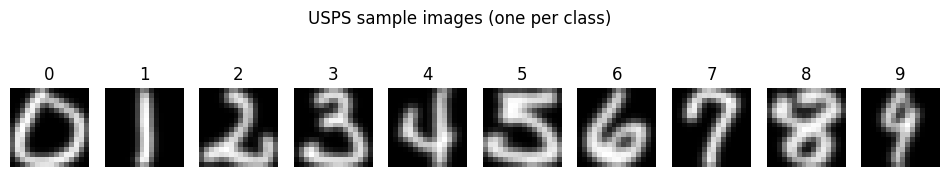

In [3]:
# One sample image per digit -- visually confirms the label remapping is correct
fig, axes = plt.subplots(1, 10, figsize=(12, 1.8))
for d, ax in enumerate(axes):
    idx = np.where(y == d)[0][0]
    ax.imshow(X[idx].reshape(16, 16), cmap='gray')
    ax.set_title(str(d)); ax.axis('off')
plt.suptitle('USPS sample images (one per class)', y=1.15)
plt.savefig('fig1_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Model Architectures

### 2.1 Neural Network (MLP) — identical to HW3

| | |
|---|---|
| **Layers / nodes** | Input **256** → Hidden 1 **256** → Hidden 2 **128** → Output **10** |
| **Activations** | **ReLU** on both hidden layers; output layer linear (softmax is inside the loss) |
| **Regularization** | **Dropout p = 0.3** after each hidden layer + **L2 weight decay 1e-4** |

### 2.2 Convolutional Neural Network (CNN)

| | |
|---|---|
| **Conv block 1** | Conv **1→32**, kernel **3×3**, pad 1 → BatchNorm → ReLU → MaxPool 2×2 (**16×16 → 8×8**) |
| **Conv block 2** | Conv **32→64**, kernel **3×3**, pad 1 → BatchNorm → ReLU → MaxPool 2×2 (**8×8 → 4×4**) |
| **Classifier** | Flatten **1024** → FC **128** → ReLU → Dropout 0.3 → FC **10** |
| **Conv / FC layers** | **2 convolutional** layers + **2 fully-connected** layers |

**Shared training setup (both models).** Loss = **Cross-Entropy**; optimizer = **Adam**
(lr **1e-3**, weight decay **1e-4**); **mini-batch** SGD (batch **128**) for **60 epochs** per
fold. Features are standardized with a `StandardScaler` **fit on the training folds only**.
**Batch normalization** in the CNN stabilizes and speeds up convergence; **dropout** and
**L2 weight decay** regularize both models.

In [4]:
class MLP(nn.Module):
    """Fully-connected NN, identical to HW3 (256-256-128-10)."""
    def __init__(self, n_in=256, n_h1=256, n_h2=128, n_out=10, p_drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, n_h1), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(n_h1, n_h2), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(n_h2, n_out),
        )
    def forward(self, x):
        return self.net(x.view(x.size(0), -1))


class CNN(nn.Module):
    """Two conv blocks (32, 64 filters, 3x3) + 2 max-pools + 2 FC layers."""
    def __init__(self, n_out=10, p_drop=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32),
            nn.ReLU(), nn.MaxPool2d(2),                 # 16x16 -> 8x8
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64),
            nn.ReLU(), nn.MaxPool2d(2),                 # 8x8 -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(128, n_out),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

print(MLP()); print(CNN())

MLP(
  (net): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)
CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_fea

## 3. Training and 5-Fold Stratified Cross-Validation

`run_fold` trains one fresh model on one fold and records the per-epoch train/validation
loss and accuracy. `cross_validate` drives the shared `StratifiedKFold` split (same
`random_state`), so the NN and CNN are evaluated on **exactly the same folds**. The `reshape`
flag turns the flat 256-vector into a 1×16×16 image for the CNN.

In [5]:
def run_fold(model_cls, X_tr, y_tr, X_va, y_va, seed, reshape):
    """Train one model on one fold; return per-epoch history + final val accuracy."""
    set_seed(seed)
    model = model_cls().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()

    def prep(a):
        t = torch.tensor(a, dtype=torch.float32)
        return t.view(-1, 1, 16, 16) if reshape else t

    train_ds = torch.utils.data.TensorDataset(prep(X_tr),
                                              torch.tensor(y_tr, dtype=torch.long))
    loader = torch.utils.data.DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,
        generator=torch.Generator().manual_seed(seed))

    X_va_t = prep(X_va).to(device)
    y_va_t = torch.tensor(y_va, dtype=torch.long).to(device)

    hist = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for _ in range(EPOCHS):
        model.train()
        loss_sum, correct, total = 0.0, 0, 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * len(xb)
            correct  += (out.argmax(1) == yb).sum().item()
            total    += len(xb)

        model.eval()
        with torch.no_grad():
            val_out  = model(X_va_t)
            val_loss = criterion(val_out, y_va_t).item()
            val_acc  = (val_out.argmax(1) == y_va_t).float().mean().item()

        hist['train_loss'].append(loss_sum / total)
        hist['train_acc'].append(correct / total)
        hist['val_loss'].append(val_loss)
        hist['val_acc'].append(val_acc)

    return hist, hist['val_acc'][-1]


def cross_validate(model_cls, name, reshape):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    histories, accuracies = [], []
    for fold, (tr, va) in enumerate(skf.split(X, y), start=1):
        scaler = StandardScaler().fit(X[tr])            # fit on training folds only
        X_tr, X_va = scaler.transform(X[tr]), scaler.transform(X[va])
        hist, acc = run_fold(model_cls, X_tr.astype(np.float32), y[tr],
                             X_va.astype(np.float32), y[va],
                             seed=SEED + fold, reshape=reshape)
        histories.append(hist); accuracies.append(acc)
        print(f'  [{name}] Experiment {fold}: '
              f'train {len(tr)} / val {len(va)} -> acc {acc:.4f}')
    return histories, accuracies

In [6]:
print('=== Training NN (MLP) ===')
nn_hist, nn_acc = cross_validate(MLP, 'NN', reshape=False)
print('\n=== Training CNN ===')
cnn_hist, cnn_acc = cross_validate(CNN, 'CNN', reshape=True)

=== Training NN (MLP) ===


  [NN] Experiment 1: train 7438 / val 1860 -> acc 0.9785


  [NN] Experiment 2: train 7438 / val 1860 -> acc 0.9769


  [NN] Experiment 3: train 7438 / val 1860 -> acc 0.9790


  [NN] Experiment 4: train 7439 / val 1859 -> acc 0.9731


...

  [CNN] Experiment 1: train 7438 / val 1860 -> acc 0.9833


  [CNN] Experiment 2: train 7438 / val 1860 -> acc 0.9860


  [CNN] Experiment 3: train 7438 / val 1860 -> acc 0.9855


  [CNN] Experiment 4: train 7439 / val 1859 -> acc 0.9833


  [CNN] Experiment 5: train 7439 / val 1859 -> acc 0.9844


## 4. Learning Curves (loss vs. epoch)

For every fold the training/validation **loss** (left) and **accuracy** (right) are plotted
per epoch, first for the NN and then for the CNN. Both models converge smoothly and plateau
well before epoch 60, and validation accuracy tracks training accuracy closely — the models
are properly trained with no severe overfitting.

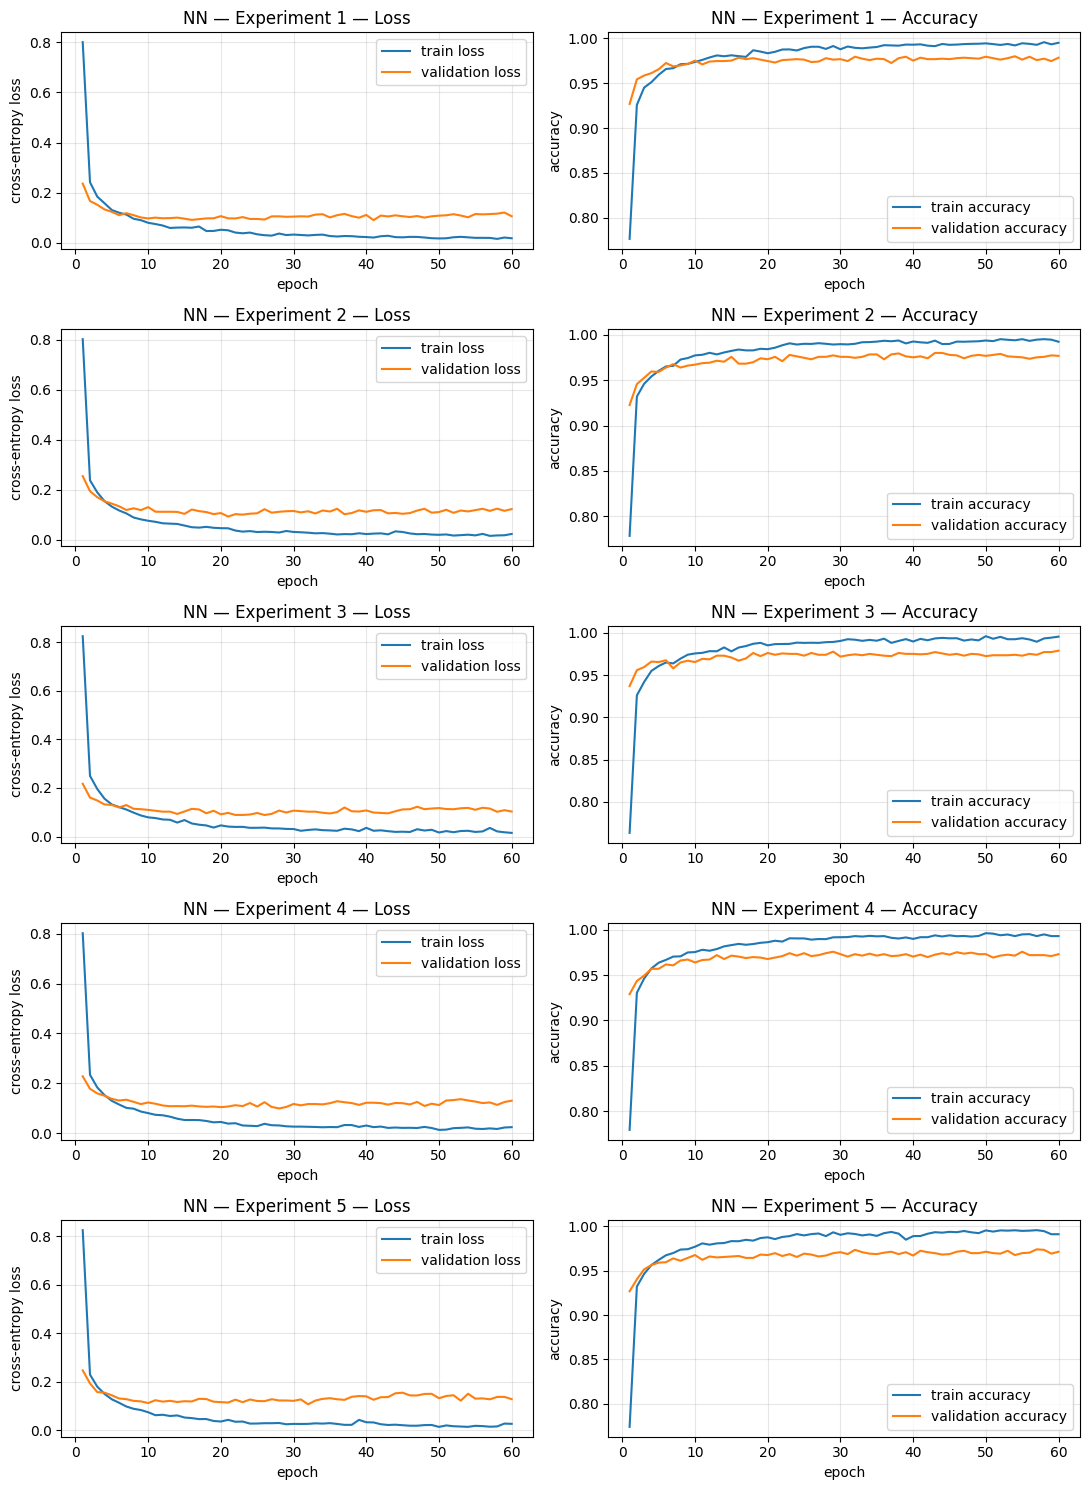

In [7]:
def plot_curves(histories, name):
    fig, axes = plt.subplots(N_FOLDS, 2, figsize=(11, 3.0 * N_FOLDS))
    ex = np.arange(1, EPOCHS + 1)
    for f, h in enumerate(histories):
        a = axes[f, 0]
        a.plot(ex, h['train_loss'], label='train loss')
        a.plot(ex, h['val_loss'], label='validation loss')
        a.set_title(f'{name} — Experiment {f+1} — Loss')
        a.set_xlabel('epoch'); a.set_ylabel('cross-entropy loss')
        a.legend(); a.grid(alpha=0.3)
        a = axes[f, 1]
        a.plot(ex, h['train_acc'], label='train accuracy')
        a.plot(ex, h['val_acc'], label='validation accuracy')
        a.set_title(f'{name} — Experiment {f+1} — Accuracy')
        a.set_xlabel('epoch'); a.set_ylabel('accuracy')
        a.legend(); a.grid(alpha=0.3)
    plt.tight_layout()
    return fig

fig = plot_curves(nn_hist, 'NN')
fig.savefig('fig2_nn_learning_curves.png', dpi=130, bbox_inches='tight')
plt.show()

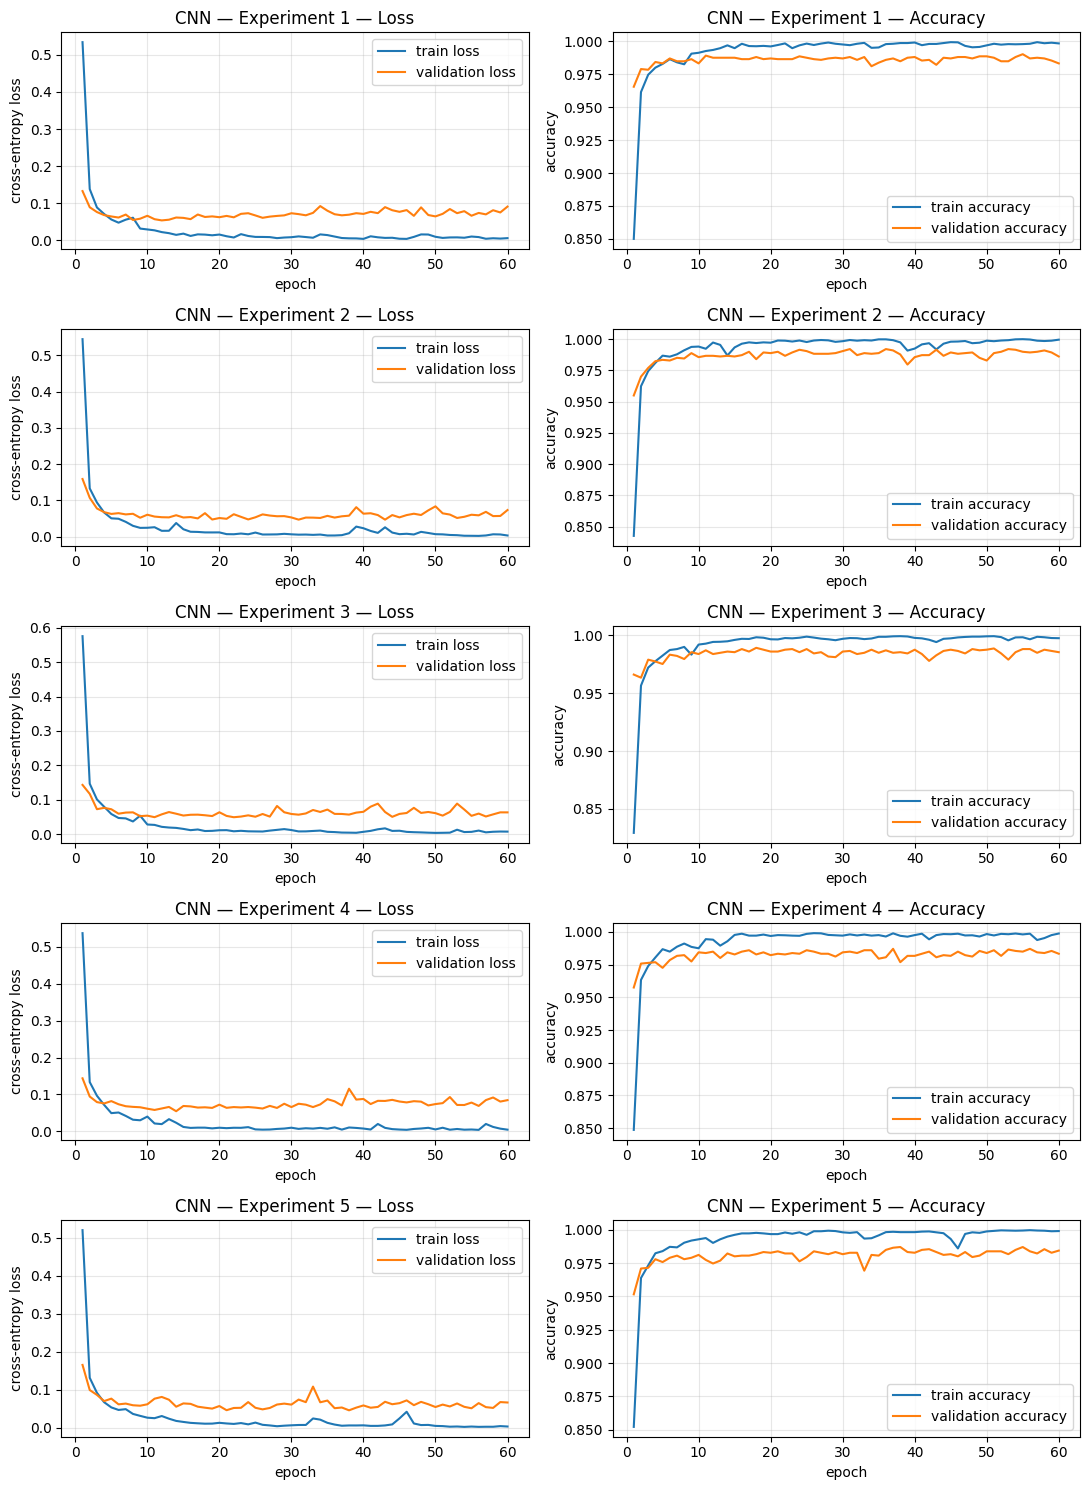

In [8]:
fig = plot_curves(cnn_hist, 'CNN')
fig.savefig('fig3_cnn_learning_curves.png', dpi=130, bbox_inches='tight')
plt.show()

### Mean validation accuracy — NN vs CNN

Averaged over the 5 folds, the CNN sits consistently **above** the NN for essentially the
whole training run and reaches a higher plateau.

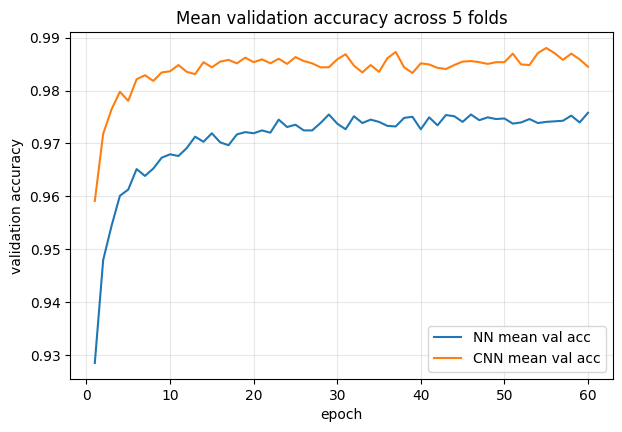

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ex = np.arange(1, EPOCHS + 1)
nn_val  = np.mean([h['val_acc'] for h in nn_hist], axis=0)
cnn_val = np.mean([h['val_acc'] for h in cnn_hist], axis=0)
ax.plot(ex, nn_val, label='NN mean val acc')
ax.plot(ex, cnn_val, label='CNN mean val acc')
ax.set_xlabel('epoch'); ax.set_ylabel('validation accuracy')
ax.set_title('Mean validation accuracy across 5 folds')
ax.legend(); ax.grid(alpha=0.3)
plt.savefig('fig4_nn_vs_cnn.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Results — NN vs CNN

In [10]:
def fmt(accs):
    return [f'{a:.4f}' for a in accs] + [f'{np.mean(accs):.4f} ± {np.std(accs):.4f}']

idx = [f'Experiment {i}' for i in range(1, N_FOLDS + 1)] + ['Average']
results = pd.DataFrame({'NN (Accuracy)': fmt(nn_acc),
                        'CNN (Accuracy)': fmt(cnn_acc)}, index=idx)
results.index.name = 'USPS 5-fold CV'
results.to_csv('results.csv')
results

,NN (Accuracy),CNN (Accuracy)
USPS 5-fold CV,,
Experiment 1,0.9785,0.9833
Experiment 2,0.9769,0.9860
Experiment 3,0.9790,0.9855
Experiment 4,0.9731,0.9833
Experiment 5,0.9715,0.9844
Average,0.9758 ± 0.0030,0.9845 ± 0.0011


## 6. Discussion & Conclusion

Under identical 5-fold stratified cross-validation the **CNN reaches 98.45% ± 0.11%**, beating
the **NN's 97.58% ± 0.30%** — about a **0.9-point** gain in accuracy and, just as importantly,
**~3× lower variance** across folds.

**Why the CNN wins.** The NN flattens the image to a 256-vector, discarding the 2-D spatial
layout, and must learn every pixel-to-pixel relationship with fully-connected weights.
The CNN instead applies small **3×3 filters** that share weights across the image, so it learns
**local, translation-tolerant features** (edges, strokes, curves) with far fewer parameters per
feature. **Pooling** adds a little shift-invariance, which matters for handwriting where the
same digit appears slightly shifted or thicker. These inductive biases fit image data, so the
CNN generalizes better and more consistently — hence both the higher mean and the smaller
fold-to-fold spread.

The gap is modest here only because USPS is small (16×16) and already near-saturated
(both models exceed 97%); on larger, higher-resolution images the convolutional advantage
would be substantially greater.